In [6]:
import xarray as xr
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import numpy as np
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
plt.rcParams.update({'font.size': 20})
import sys
sys.path.append("/home/jupyter-vincent2/vincent/process_profiles/noteboooks_2026/functions")
from create_rec_datasets import r_analysis_df

In [7]:
### Bathy
ncfile_etopo1 = "/media/disk2/vincent/process_profiles/data/external_supports/GEBCO_ker_large.nc"
ds_topo = xr.open_dataset(ncfile_etopo1)
elevation = ds_topo.elevation[::10,::10]
### Fronts
ds_front = xr.open_dataset("/media/disk2/vincent/process_profiles/data/external_supports/62985.nc")

### Datasets
ds_CMA,df_CMA,df_XIEST_CMA,df_PHI_CMA,df_GRID_CMA,df_MU_CMA,df_lambda_CMA = r_analysis_df("CMA_masked")
ds_G,df_G,df_XIEST_G,df_PHI_G,df_GRID_G,df_MU_G,df_lambda_G = r_analysis_df("GLORYS_masked",dense=True)
ds_CL,df_CL,df_XIEST_CL,df_PHI_CL,df_GRID_CL,df_MU_CL,df_lambda_CL = r_analysis_df("GLORYS_CL_masked")

legend_fs = 15
G_color = "#0D160B"
CMA_color = "#008DD5"
CL_color = "#CB152B"

# Mask all variables that include both ("long", "lat") dimensions
# Keep only the selected box; outside becomes NaN
lon_min = 68.25
lon_max = 70.75
lat_min = -50
lat_max = -48

def apply_spatial_mask(ds, lon_min, lon_max, lat_min, lat_max):
    lon2d, lat2d = xr.broadcast(ds["long"], ds["lat"])
    area_mask = (
        (lon2d >= lon_min) & (lon2d <= lon_max) &
        (lat2d >= lat_min) & (lat2d <= lat_max)
    )

    ds_out = ds.copy()
    for v in ds_out.data_vars:
        if {"long", "lat"}.issubset(ds_out[v].dims):
            ds_out[v] = ds_out[v].where(~area_mask)
    return ds_out

ds_CMA = apply_spatial_mask(ds_CMA, lon_min, lon_max, lat_min, lat_max)
ds_G   = apply_spatial_mask(ds_G, lon_min, lon_max, lat_min, lat_max)
ds_CL  = apply_spatial_mask(ds_CL, lon_min, lon_max, lat_min, lat_max)

### Old datasets
ds_CMA_og = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/CMA_anom.nc")
ds_CMA_og = ds_CMA_og.rename({"longitude": "long", "latitude": "lat"})
ds_CMA_og["time"] = ds_G.time
ds_CMA_og["lat"] = ds_G.lat
ds_CMA_og["long"] = ds_G.long

ds_CL_og = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/GLORYS_CL_anom.nc")
ds_CL_og = ds_CL_og.where(ds_CL_og.time<pd.to_datetime("2024-01-01"), drop=True)
ds_CL_og = ds_CL_og.rename({"longitude": "long", "latitude": "lat"})
ds_CL_og["time"] = ds_G.time
ds_CL_og["lat"] = ds_G.lat
ds_CL_og["long"] = ds_G.long

ds_G_og = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/GLORYS_anom.nc")
ds_G_og = ds_G_og.where(ds_G_og.time<pd.to_datetime("2024-01-01"), drop=True)
ds_G_og = ds_G_og.rename({"longitude": "long", "latitude": "lat"})
ds_G_og["time"] = ds_G.time
ds_G_og["lat"] = ds_G.lat
ds_G_og["long"] = ds_G.long

204
204
204


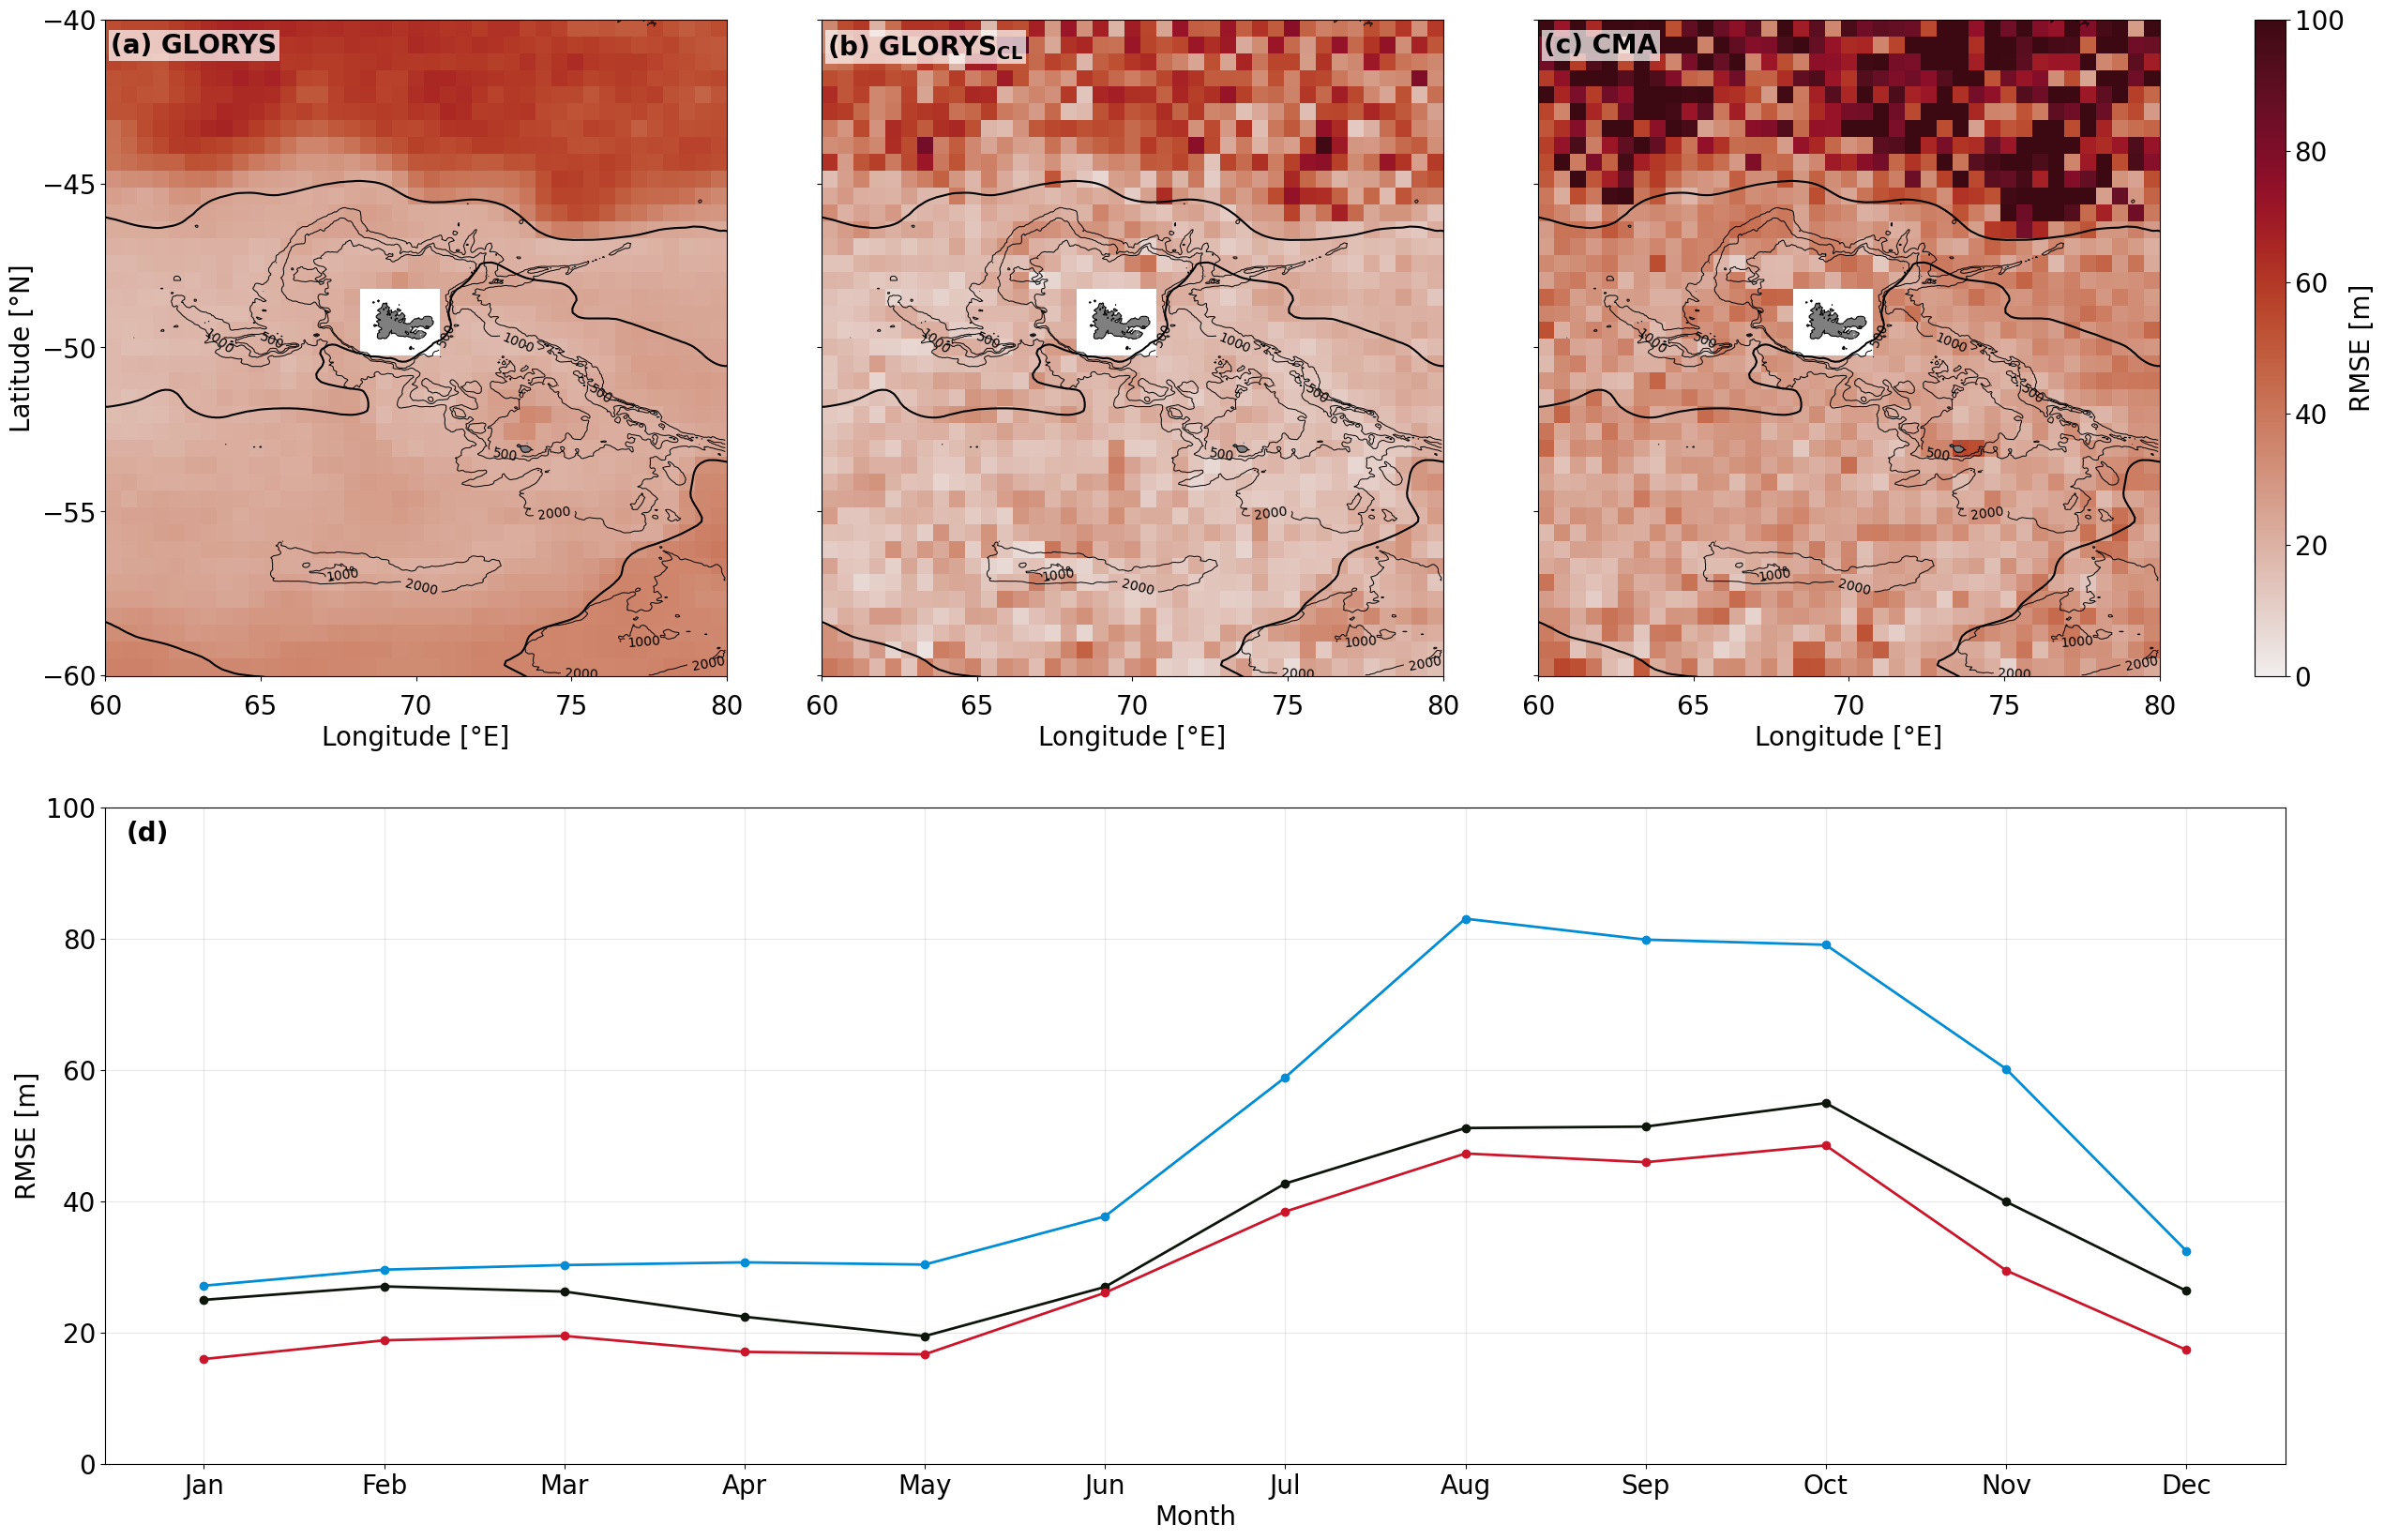

The mean RMSE of GLORYS: 32.73
The standard deviation of the RMSE of GLORYS is: 14.52
The mean RMSE of GLORYS_CL: 26.38
The standard deviation of the RMSE of GLORYS_CL is: 15.45
The mean RMSE of CMA: 43.03
The standard deviation of the RMSE of CMA is: 30.60


In [10]:
# --- helpers ---
def compute_qe(ds_pred, ds_ref, var="mld", mask=None):
    err = ds_pred[var] - ds_ref[var]
    if mask is not None:
        err = err.where(mask)
    qe = np.sqrt((err**2).mean(dim="time", skipna=True))
    return qe, qe.where(qe > 0)


def monthly_rmse(ds_pred, ds_ref, var="mld", mask=None):
    err = ds_pred[var] - ds_ref[var]
    if mask is not None:
        err = err.where(mask)
    return np.sqrt((err**2).groupby("time.month").mean(skipna=True).mean(["lat", "long"], skipna=True))


def add_common_map_layers(ax):
    ax.contour(
        elevation.lon, elevation.lat, elevation,
        levels=[0], colors="k", linewidths=0.8
    )
    (elevation / elevation).where(elevation > 0).plot(
        add_colorbar=False, cmap="gist_yarg", ax=ax
    )
    cs = (-elevation).plot.contour(
        levels=(500, 1000, 2000), colors=["black"], linewidths=0.7, ax=ax
    )
    ax.plot(ds_front.LonSAF.where(ds_front.LatSAF > -50), ds_front.LatSAF.where(ds_front.LatSAF > -50), c="k")
    ax.plot(ds_front.LonPF, ds_front.LatPF, c="k")
    ax.plot(ds_front.LonSACCF, ds_front.LatSACCF, c="k")
    ax.clabel(cs, inline=True, fmt="%1.0f", fontsize=10)
    ax.set_xticks([60, 65, 70, 75, 80])
    ax.set_yticks([-60, -55, -50, -45, -40])


# --- plotting setup ---
cmap = cmo.amp

qe_g, qe_plot_g = compute_qe(ds_G, ds_G_og)
qe_cl, qe_plot_cl = compute_qe(ds_CL, ds_CL_og)
qe_cma, qe_plot_cma = compute_qe(ds_CMA, ds_CMA_og)

# shared color scale across the 3 top maps
all_qe_vals = np.concatenate([
    qe_plot_g.values.ravel(),
    qe_plot_cl.values.ravel(),
    qe_plot_cma.values.ravel()
])
vmin = 0
vmax = 100

fig = plt.figure(figsize=(30, 20))
gs = fig.add_gridspec(
    2, 4,
    width_ratios=[1, 1, 1, 0.05],
    height_ratios=[1, 1],
    wspace=0.2, hspace=0.2
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 2], sharey=ax1)
cax = fig.add_subplot(gs[0, 3])
ax4 = fig.add_subplot(gs[1, :])

map_items = [
    (ax1, ds_G, qe_plot_g, "(a) GLORYS", "Latitude [°N]"),
    (ax2, ds_CL, qe_plot_cl, r"(b) GLORYS$_{\mathregular{CL}}$", " "),
    (ax3, ds_CMA, qe_plot_cma, "(c) CMA", " "),
]

for ax, ds_i, qe_i, panel_txt, ylab in map_items:
    pcm_last = ax.pcolormesh(
        ds_i["long"],
        ds_i["lat"],
        qe_i.transpose("lat", "long"),
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    add_common_map_layers(ax)
    ax.set_xlabel("Longitude [°E]")
    ax.set_ylabel(ylab)
    ax.text(
        0.01, 0.98, panel_txt,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=20, fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2),
    )
    ax.tick_params(axis="x", which="major", pad=10)

# keep y tick labels only on the left top plot
ax2.tick_params(axis="y", labelleft=False)
ax3.tick_params(axis="y", labelleft=False)

# shared colorbar for the 3 top maps
cb = fig.colorbar(pcm_last, cax=cax)
cb.set_label("RMSE [m]")


# --- monthly RMSE timeseries ---
RMSE_G = monthly_rmse(ds_G, ds_G_og)
RMSE_CL = monthly_rmse(ds_CL, ds_CL_og)
RMSE_CMA = monthly_rmse(ds_CMA, ds_CMA_og)

for data_ts, color_ts, label_ts in zip(
    [RMSE_G, RMSE_CL, RMSE_CMA],
    [G_color, CL_color, CMA_color],
    ["GLORYS", "GLORYS_CL", "CMA"]
):
    ax4.plot(data_ts.month, data_ts, color=color_ts, lw=2, marker="o", label=label_ts)

ax4.set_xlabel("Month")
ax4.set_ylabel("RMSE [m]")
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax4.grid(True, alpha=0.3)
ax4.set_ylim(0, 100)
ax4.text(
    0.01, 0.98, "(d)",
    transform=ax4.transAxes,
    ha="left", va="top",
    fontsize=20, fontweight="bold",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2),
)

plt.show()

print(f"The mean RMSE of GLORYS: {qe_g.mean().item():.2f}")
print(f"The standard deviation of the RMSE of GLORYS is: {qe_g.std().item():.2f}")
print(f"The mean RMSE of GLORYS_CL: {qe_cl.mean().item():.2f}")
print(f"The standard deviation of the RMSE of GLORYS_CL is: {qe_cl.std().item():.2f}")
print(f"The mean RMSE of CMA: {qe_cma.mean().item():.2f}")
print(f"The standard deviation of the RMSE of CMA is: {qe_cma.std().item():.2f}")

fig.savefig("/home/jupyter-vincent2/vincent/process_profiles/figures_2026/Figure_6_RMSE.png", dpi=300, bbox_inches="tight")
